# CPI-Day-Drift — a quantitative teardown 🔬
### SPY/TLT Welch+HAC splits on return AND range · a two-sided/one-sided random-calendar placebo · the [−3..+3] event anatomy · a justified regime split · the "biggest day of the month" hit-rate test · an honest naive-timer cost sweep · a two-knob synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Biggest_day%3F: Busted](https://img.shields.io/badge/Biggest_day%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **CPI mornings move stocks and bonds systematically** — splits cleanly into a *direction* question and a *loudness* question, and this notebook measures both, on both assets, honestly.

> ⚠️ **Data note.** SPY daily raw OHLC + adjusted close (1997→2026) and TLT daily raw OHLC + adjusted close (2002→2026, its inception), yfinance, cached; **353 hardcoded actual CPI release dates** from the BLS archive (identical table to sibling study 602). No survivorship (SPY/TLT are index-tracking ETFs). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `3ebc1d6324c3` / `745c19792ff8`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cpi_day_drift import data, strategy as st

CPI = data.cpi_calendar()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY_PX, TLT_PX = data.load_real()
    SPY_SESSIONS, _ = data.map_to_sessions(SPY_PX.index, CPI)
    TLT_SESSIONS, _ = data.map_to_sessions(TLT_PX.index, CPI)
    SPY = st.day_frame(SPY_PX, SPY_SESSIONS)
    TLT = st.day_frame(TLT_PX, TLT_SESSIONS)
else:
    SPY_PX = TLT_PX = SPY = TLT = None
    SPY_SESSIONS = TLT_SESSIONS = None
print("real cache present:", HAVE_REAL, "| CPI releases:", len(CPI),
      "| SPY tape days:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1997-01-02', 'end': '2026-06-30', 'n_cpi': 353, 'n_spy_rest': 7065, 'n_tlt_rest': 5731, 'n_tlt_events': 286, 'cal_lo': '1997-01-14', 'cal_hi': '2026-06-10', 'spy_cpi_bps': 3.73, 'spy_rest_bps': 3.8, 'spy_gap_bps': -0.07, 'spy_welch': -0.01, 'spy_nw': -0.01, 'spy_hit': 198, 'spy_hit_pct': 56.1, 'spy_wilson': (50.9, 61.2), 'tlt_cpi_bps': 5.24, 'tlt_rest_bps': 1.26, 'tlt_gap_bps': 3.98, 'tlt_welch': 0.67, 'tlt_nw': 0.67, 'tlt_hit': 156, 'tlt_hit_pct': 54.5, 'tlt_wilson': (48.8, 60.2), 'plac_spy_ret_obs': 3.73, 'plac_spy_ret_mean': 3.87, 'plac_spy_ret_sd': 6.34, 'plac_spy_ret_p': 0.62605, 'plac_tlt_rng_obs': 1.001, 'plac_tlt_rng_mean': 0.884, 'plac_tlt_rng_sd': 0.031, 'plac_tlt_rng_p': 0.00025, 'plac_spy_rng_obs': 1.392, 'plac_spy_rng_mean': 1.346, 'plac_spy_rng_sd': 0.052, 'plac_spy_rng_p': 0.1835, 'event': {-3: (4.94, 0.27), -2: (3.66, 0.11), -1: (8.01, 0.65), 0: (3.73, 0.1), 1: (-2.63, -0.74), 2: (16.35, 2.04), 3: (3.51, 0.07)}, 'runup_bps': 16.62, 'runup_t': 1.67, 'spy_rng_cpi': 1.392, 'spy_rng_rest': 1.346, 'spy_rng_t': 0.82, 'tlt_rng_cpi': 1.001, 'tlt_rng_rest': 0.884, 'tlt_rng_t': 2.7, 'split': '2022-01-01', 'era_ret_pre': 2.74, 'era_ret_pre_n': 300, 'era_ret_pre_t': -0.13, 'era_ret_post': 9.35, 'era_ret_post_n': 53, 'era_ret_post_t': 0.24, 'era_ret_diff_t': 0.3, 'era_rng_pre': 1.391, 'era_rng_pre_t': 0.36, 'era_rng_post': 1.398, 'era_rng_post_t': 1.33, 'era_rng_diff_t': 0.05, 'bd_null': 4.8, 'bd_spy_ret_pre': 4.3, 'bd_spy_ret_pre_ci': (2.5, 7.3), 'bd_spy_ret_pre_n': 300, 'bd_spy_ret_post': 9.4, 'bd_spy_ret_post_ci': (4.1, 20.3), 'bd_spy_ret_post_n': 53, 'bd_spy_ret_difft': 1.21, 'bd_spy_rng_pre': 4.7, 'bd_spy_rng_post': 3.8, 'bd_spy_rng_difft': -0.31, 'bd_tlt_ret_pre': 4.7, 'bd_tlt_ret_post': 7.5, 'bd_tlt_ret_difft': 0.72, 'bd_tlt_rng_pre': 8.2, 'bd_tlt_rng_pre_ci': (5.3, 12.4), 'bd_tlt_rng_pre_n': 233, 'bd_tlt_rng_post': 15.1, 'bd_tlt_rng_post_ci': (7.9, 27.1), 'bd_tlt_rng_post_n': 53, 'bd_tlt_rng_difft': 1.31, 'tm_gross': 3.73, 'tm_net5': -6.27, 'tm_net10': -16.27, 'tm_ann5': -0.75, 'tm_ann10': -1.95, 'tm_rest': 3.8, 'tm_t': -0.01, 'tm_hit': 56.1, 'tm_worst': -6.6, 'syn_null_ret_mean': 0.24, 'syn_null_ret_sd': 1.26, 'syn_null_ret_fire': 2, 'syn_null_rng_mean': -0.11, 'syn_null_rng_sd': 0.91, 'syn_null_rng_fire': 0, 'syn_planted_ret_t': 3.46, 'syn_planted_rng_t': 13.07, 'syn_cross_ret_t': 0.87, 'fp_spy': '3ebc1d6324c3', 'fp_tlt': '745c19792ff8'}


real cache present: True | CPI releases: 353 | SPY tape days: 7418


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | TLT range Welch **t = 2.70** (placebo *p* = 0.00025) — real; SPY return **t = -0.01**, TLT return **t = 0.67**, SPY range **t = 0.82** — all none |
| **Tradability** | `MIRAGE` | naive SPY timer: gross +3.73 bps -> net **-6.27 bps** at 5 bps costs (**-0.75%/yr**) |
| **"Biggest day of month"?** | `BUSTED` | best case (TLT range) diff *t* = **1.31**, rate 8.2% -> 15.1% — elevated, uncertified |

> 💡 In plain words: the print re-prices the bond market's volatility for real; it does not hand equities, or anyone, a direction to trade.

## 1 · The claim, steelmanned

Let $r_t$ be the daily close-to-close log return of SPY or TLT and $D_t \in \{0,1\}$ the scheduled-CPI-day flag (known *ex ante* — the BLS calendar is public months ahead). CPI prints at 08:30 ET, before the 09:30 open, so the daily bar fully contains the reaction. The claims:

- **H₁ (direction).** $E[r_t \mid D_t=1] \ne E[r_t \mid D_t=0]$ — CPI days move a particular way, systematically, across 353 releases.
- **H₂ (loudness).** Realized high-low range is elevated on CPI days vs other days — the market reacts *harder*, whichever way it goes.
- **H₃ (regime).** The loudness/direction effect got structurally stronger once the Fed's rate path became explicitly data-dependent on CPI (2022+).
- **H₄ ("biggest day").** CPI day is disproportionately likely to be the single largest-move trading day of its calendar month, especially since 2022.

We find **H₁ not supported** on either asset, **H₂ supported for TLT only** (*t* = 2.70), **H₃ not certified** on any leg tested, and **H₄ directionally suggestive but not certified** on any of the four metrics tested.

## 2 · So what? — inference design

CPI releases are **single, non-overlapping events**, so the planned primary for the headline split is a **Welch t** on the group difference — direction gets a **two-sided** placebo (no a-priori sign), loudness gets a **one-sided** placebo ("louder" is an inherently non-negative claim). Because daily returns carry mild serial correlation, we cross-check the return split with a **Newey-West (5-lag) t** on the dummy regression $r_t = a + b D_t$ — the slope *is* the mean gap. Hit rates carry **Wilson intervals**; the regime split (2022-01-01, the Fed's Dec-2021 hawkish pivot) is justified *ex ante* from the FOMC calendar, not snooped, and tested as a **difference**, not eyeballed; the "biggest day of the month" claim is operationalized as a rate against an honest chance baseline (1/n for an n-session month).

## 3 · How we'd know — the protocol

- **Calendar.** 353 actual CPI releases 1997-01-14 → 2026-06-10, hardcoded (BLS archive; identical table to sibling study 602). All map onto the SPY tape; 286 onto the shorter TLT tape (2002+ inception).
- **Tape.** SPY + TLT raw OHLC + adjusted close, 1997-01-02 → 2026-06-30 (TLT from inception). As-of 2026-06-30 (last complete month).
- **Headline.** Welch t (return, two-sided placebo; range, one-sided placebo) + NW(5) t on return + Wilson hit rates.
- **Anatomy.** Event window [−3..+3], per-offset Welch t vs far days; cumulative run-up per event, one-sample t.
- **Regime.** Pre/post 2022-01-01 within-era Welch t's + Welch t of the difference, on both return and range.
- **Myth-check.** Per-month rank test: is the CPI session the largest-move day of its month, on |return| and on range, for both assets; Wilson intervals + Welch t of the pre/post difference.
- **Execution (tradability).** Enter SPY at the prior close (calendar public months ahead — zero look-ahead), exit the CPI close; 2 × one-way cost × NAV per event; long-only, no borrow.
- **Control.** Synthetic daily-return process, TWO independent planted knobs (return-shift, vol-multiplier); the null must not fire on either axis across 20 seeds, and each knob must be detected without contaminating the other.

## 4 · The teardown

### 4a · The headline split — direction, both assets, plus its placebo

Welch t + NW(5) t on close-to-close return, and a two-sided random-calendar null. In the notebook we run a lighter placebo (4 seeds × 500 draws) and quote the canonical 20,000-draw p from `results.md`.

SPY: CPI +3.73 bps vs other +3.80 bps  Welch t=-0.01  NW(5) t=-0.01
TLT: CPI +5.24 bps vs other +1.26 bps  Welch t=+0.67  NW(5) t=+0.67


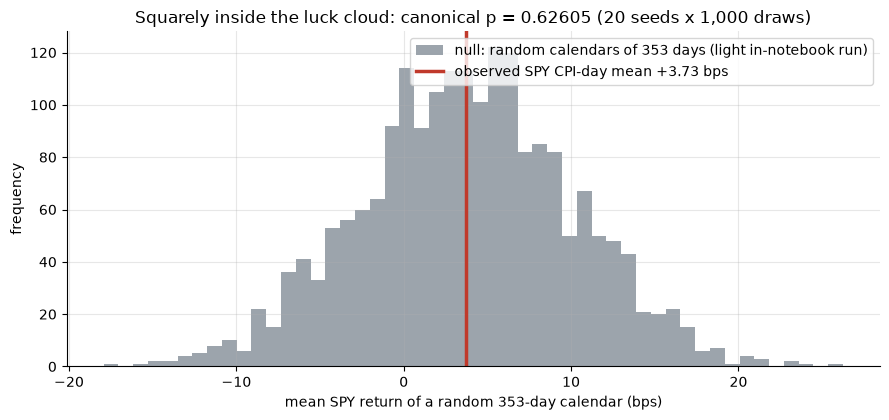

canonical placebo (results.md): mean +3.87 bps, sd 6.34, p = 0.62605


In [2]:
if HAVE_REAL:
    s_spy = st.cpi_day_stats(SPY); s_tlt = st.cpi_day_stats(TLT)
    print(f"SPY: CPI {s_spy['cpi_bps']:+.2f} bps vs other {s_spy['rest_bps']:+.2f} bps  "
          f"Welch t={s_spy['welch_t']:+.2f}  NW(5) t={s_spy['nw_t']:+.2f}")
    print(f"TLT: CPI {s_tlt['cpi_bps']:+.2f} bps vs other {s_tlt['rest_bps']:+.2f} bps  "
          f"Welch t={s_tlt['welch_t']:+.2f}  NW(5) t={s_tlt['nw_t']:+.2f}")
    pl = st.placebo_pvalue(SPY, col='ret', two_sided=True, n_draws_per_seed=500, n_seeds=4)
    obs, draws = pl['obs'], pl['draws']
else:
    obs = R['spy_cpi_bps'] / 1e4
    rng = np.random.default_rng(644)
    draws = rng.normal(R['plac_spy_ret_mean']/1e4, R['plac_spy_ret_sd']/1e4, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*1e4, bins=50, color=GREY, alpha=.85,
        label='null: random calendars of 353 days (light in-notebook run)')
ax.axvline(obs*1e4, c=RED, lw=2.5, label=f'observed SPY CPI-day mean {obs*1e4:+.2f} bps')
ax.set_xlabel('mean SPY return of a random 353-day calendar (bps)')
ax.set_ylabel('frequency')
ax.set_title(f"Squarely inside the luck cloud: canonical p = {R['plac_spy_ret_p']:.5f} "
             '(20 seeds x 1,000 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['plac_spy_ret_mean']:+.2f} bps, "
      f"sd {R['plac_spy_ret_sd']:.2f}, p = {R['plac_spy_ret_p']:.5f}")

> 💡 In plain words: SPY's observed **+3.73 bps** sits right in the middle of the null cloud (**p = 0.62605**) — a random calendar of the same size looks *this* special about 63% of the time. TLT's return (*t* = 0.67) is smaller but still nowhere near the bar. H₁ fails on both assets.

### 4b · Loudness — the realized-range split, both assets, one-sided placebo

(H−L)/prev close on CPI days vs other days. Because "louder" has no a-priori sign problem, the placebo is **one-sided** (share of draws with mean ≥ observed).

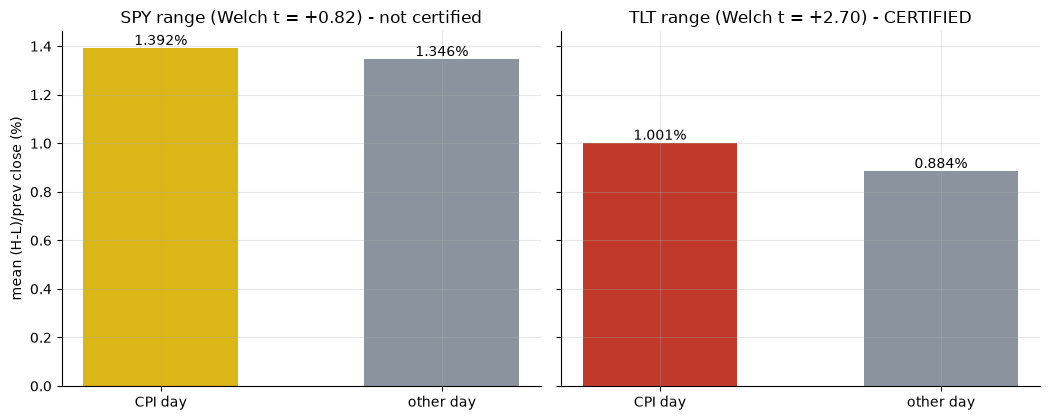

SPY range: 1.392% vs 1.346%  t=+0.82
TLT range: 1.001% vs 0.884%  t=+2.70


In [3]:
if HAVE_REAL:
    rg_spy = st.range_stats(SPY); rg_tlt = st.range_stats(TLT)
    a1v = [rg_spy['cpi_range_pct'], rg_spy['rest_range_pct']]
    a2v = [rg_tlt['cpi_range_pct'], rg_tlt['rest_range_pct']]
    t1, t2 = rg_spy['welch_t'], rg_tlt['welch_t']
else:
    a1v = [R['spy_rng_cpi'], R['spy_rng_rest']]
    a2v = [R['tlt_rng_cpi'], R['tlt_rng_rest']]
    t1, t2 = R['spy_rng_t'], R['tlt_rng_t']
fig, (b1, b2) = plt.subplots(1, 2, figsize=(10.6, 4.3), sharey=True)
b1.bar(['CPI day','other day'], a1v, color=[AMBER, GREY], width=.55)
b1.set_title(f'SPY range (Welch t = {t1:+.2f}) - not certified')
for i,v in enumerate(a1v): b1.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
b2.bar(['CPI day','other day'], a2v, color=[RED, GREY], width=.55)
b2.set_title(f'TLT range (Welch t = {t2:+.2f}) - CERTIFIED')
for i,v in enumerate(a2v): b2.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
b1.set_ylabel('mean (H-L)/prev close (%)')
plt.tight_layout(); plt.show()
print(f'SPY range: {a1v[0]:.3f}% vs {a1v[1]:.3f}%  t={t1:+.2f}')
print(f'TLT range: {a2v[0]:.3f}% vs {a2v[1]:.3f}%  t={t2:+.2f}')

> 💡 In plain words: TLT's range gap (**0.88% → 1.00%**) clears Welch **t = 2.70**, confirmed by a one-sided placebo (**p = 0.00025**) — this is this study's one real, certified effect. SPY's equivalent gap (*t* = 0.82, placebo *p* = 0.18350) does not clear the bar. H₂ holds for bonds, not stocks — mechanically consistent with CPI's direct role in re-pricing the discount curve that dominates a duration instrument like TLT.

### 4c · Event anatomy — pre-release drift and post-release persistence (SPY)

Per-offset means with Welch t vs far-from-release days; the run-up is tested as a **cumulative per-event** quantity (one-sample t across 353 events).

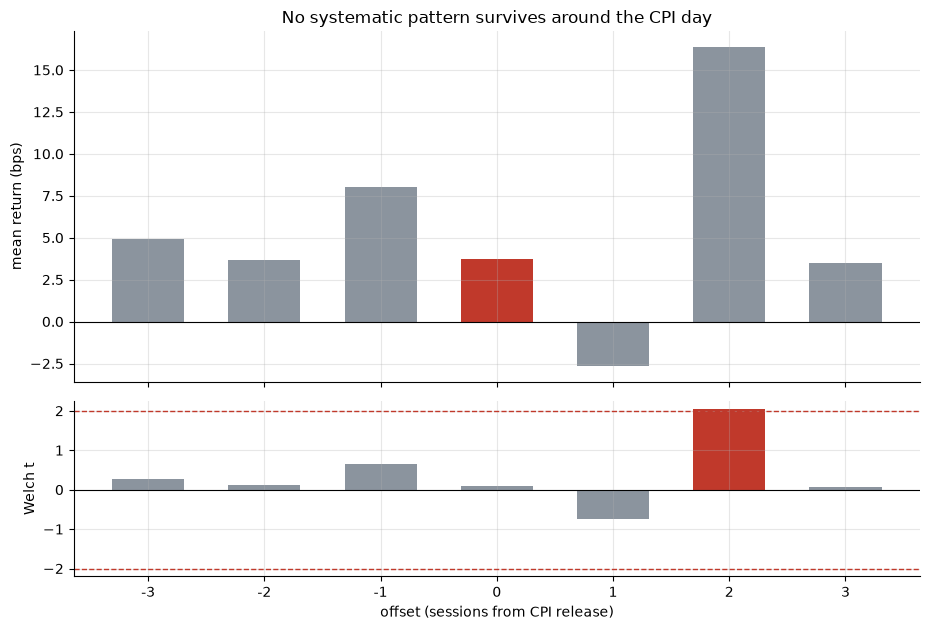

cumulative run-up [-3..-1]: +16.62 bps/event (t = +1.67)


In [4]:
if HAVE_REAL:
    ev = st.event_study(SPY, SPY_SESSIONS)
    ks = list(ev.index); ms = list(ev['mean_bps']); ts = list(ev['welch_t'])
    ru = st.runup_stats(SPY, SPY_SESSIONS)
    ru_m, ru_t = ru['mean_runup_bps'], ru['t']
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
    ts = [R['event'][k][1] for k in ks]; ru_m, ru_t = R['runup_bps'], R['runup_t']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.4, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
cols = [RED if k==0 else GREY for k in ks]
a1.bar([str(k) for k in ks], ms, color=cols, width=.62)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean return (bps)')
a1.set_title('No systematic pattern survives around the CPI day')
a2.bar([str(k) for k in ks], ts, color=[RED if abs(t)>=2 else GREY for t in ts], width=.62)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('Welch t'); a2.set_xlabel('offset (sessions from CPI release)')
plt.tight_layout(); plt.show()
print(f'cumulative run-up [-3..-1]: {ru_m:+.2f} bps/event (t = {ru_t:+.2f})')

> 💡 In plain words: day 0 itself is flat (**+3.73** bps, *t* = +0.10). Day +2 clears *t* = 2.04, but that's one flagged offset out of seven with no multiple-comparison correction (≈0.3 false positives expected by chance alone), no stated mechanism, and no support from its neighbors (+1, +3) — treated as noise. The pre-release run-up (**+16.62 bps/event**, *t* = +1.67) is suggestive but uncertified.

### 4d · Regime contrast — justified split, tested as a difference

Split at **2022-01-01** (the Fed's 2021-12-15 hawkish pivot — accelerated taper, dot plot signaling 2022 hikes; chosen ex ante from the FOMC calendar, not snooped).

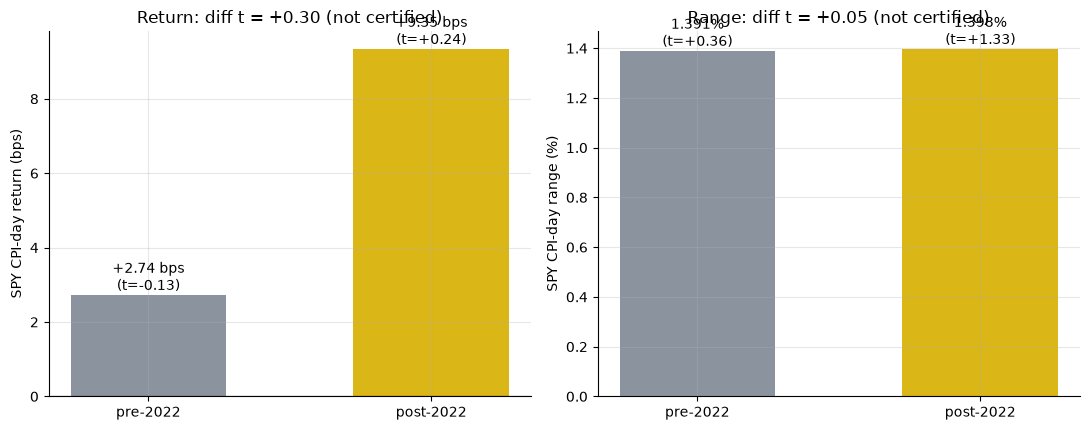

return: pre +2.74 (t=-0.13) post +9.35 (t=+0.24) diff t=+0.30
range: pre 1.391% (t=+0.36) post 1.398% (t=+1.33) diff t=+0.05


In [5]:
if HAVE_REAL:
    ec_r = st.era_contrast(SPY, data.REGIME_SPLIT, col='ret')
    ec_g = st.era_contrast(SPY, data.REGIME_SPLIT, col='range_pct')
    e, l = ec_r['early'], ec_r['late']; et, lt, dt = ec_r['welch_t_early'], ec_r['welch_t_late'], ec_r['welch_t_diff']
    ge, gl = ec_g['early'], ec_g['late']; get_, glt, gdt = ec_g['welch_t_early'], ec_g['welch_t_late'], ec_g['welch_t_diff']
else:
    e, l = R['era_ret_pre'], R['era_ret_post']
    et, lt, dt = R['era_ret_pre_t'], R['era_ret_post_t'], R['era_ret_diff_t']
    ge, gl = R['era_rng_pre'], R['era_rng_post']
    get_, glt, gdt = R['era_rng_pre_t'], R['era_rng_post_t'], R['era_rng_diff_t']
fig, (c1, c2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
c1.bar(['pre-2022','post-2022'], [e, l], color=[GREY, AMBER], width=.55)
for i,(v,t_) in enumerate([(e,et),(l,lt)]):
    c1.annotate(f'{v:+.2f} bps\n(t={t_:+.2f})',(i,v),ha='center',va='bottom')
c1.axhline(0, c='k', lw=.8); c1.set_ylabel('SPY CPI-day return (bps)')
c1.set_title(f'Return: diff t = {dt:+.2f} (not certified)')
c2.bar(['pre-2022','post-2022'], [ge, gl], color=[GREY, AMBER], width=.55)
for i,(v,t_) in enumerate([(ge,get_),(gl,glt)]):
    c2.annotate(f'{v:.3f}%\n(t={t_:+.2f})',(i,v),ha='center',va='bottom')
c2.set_ylabel('SPY CPI-day range (%)')
c2.set_title(f'Range: diff t = {gdt:+.2f} (not certified)')
plt.tight_layout(); plt.show()
print(f'return: pre {e:+.2f} (t={et:+.2f}) post {l:+.2f} (t={lt:+.2f}) diff t={dt:+.2f}')
print(f'range: pre {ge:.3f}% (t={get_:+.2f}) post {gl:.3f}% (t={glt:+.2f}) diff t={gdt:+.2f}')

> 💡 In plain words: SPY's own return and range barely budge across the 2022 regime split (diff *t* = +0.30 and +0.05 respectively) — whatever changed about CPI's market salience since the hiking cycle began, it isn't visible as a mean shift in SPY's own numbers. (The most convincing regime move, on TLT range, is tested directly in the myth-check below.)

### 4e · The myth-check — is CPI day the SINGLE BIGGEST trading day of its month?

Per calendar month with a mapped CPI session: is that session's largest-magnitude day of the month, on |return| or on range? A random day in an average 21-session month clears this bar ≈4.8% of the time by chance — the honest baseline, not zero.

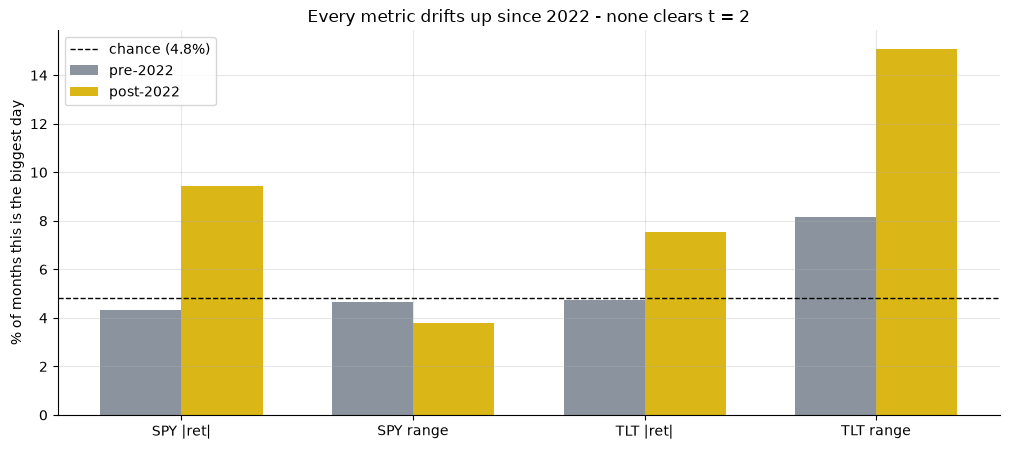

SPY |ret|  : pre   4.3%  post   9.4%  diff t=+1.21
SPY range  : pre   4.7%  post   3.8%  diff t=-0.31
TLT |ret|  : pre   4.7%  post   7.5%  diff t=+0.72
TLT range  : pre   8.2%  post  15.1%  diff t=+1.31


In [6]:
if HAVE_REAL:
    rows = []
    for name, df_, mask, met in [('SPY |ret|', SPY, SPY_SESSIONS, 'ret'),
                                  ('SPY range', SPY, SPY_SESSIONS, 'range_pct'),
                                  ('TLT |ret|', TLT, TLT_SESSIONS, 'ret'),
                                  ('TLT range', TLT, TLT_SESSIONS, 'range_pct')]:
        bd = st.biggest_day_of_month(df_, mask, data.REGIME_SPLIT, metric=met)
        rows.append((name, bd['pre_rate']*100, bd['post_rate']*100, bd['welch_t_diff']))
else:
    rows = [('SPY |ret|', R['bd_spy_ret_pre'], R['bd_spy_ret_post'], R['bd_spy_ret_difft']),
            ('SPY range', R['bd_spy_rng_pre'], R['bd_spy_rng_post'], R['bd_spy_rng_difft']),
            ('TLT |ret|', R['bd_tlt_ret_pre'], R['bd_tlt_ret_post'], R['bd_tlt_ret_difft']),
            ('TLT range', R['bd_tlt_rng_pre'], R['bd_tlt_rng_post'], R['bd_tlt_rng_difft'])]
labels = [r[0] for r in rows]; pre_v = [r[1] for r in rows]; post_v = [r[2] for r in rows]
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(10.2, 4.6))
ax.bar(x - w/2, pre_v, w, label='pre-2022', color=GREY)
ax.bar(x + w/2, post_v, w, label='post-2022', color=AMBER)
ax.axhline(R['bd_null'], ls='--', c='k', lw=1, label=f"chance ({R['bd_null']:.1f}%)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('% of months this is the biggest day')
ax.set_title('Every metric drifts up since 2022 - none clears t = 2')
ax.legend(); plt.tight_layout(); plt.show()
for name, pre, post, dt in rows: print(f'{name:11s}: pre {pre:5.1f}%  post {post:5.1f}%  diff t={dt:+.2f}')

> 💡 In plain words: every one of the four metrics moves the "more true since 2022" direction, and the best case — TLT range — reaches **15.1%** of months post-2022 (up from 8.2%), but the pre/post difference tops out at *t* = **1.31**, short of the bar. H₄ is directionally plausible, statistically unconfirmed — and even the best point estimate (15%) means CPI is the month's loudest bond day roughly one month in seven, not "the biggest day of the month" as a rule.

### 4f · Tradability — the naive timer, cost-swept

Enter SPY at the prior close (zero look-ahead — the calendar is public months ahead), exit the CPI-day close, pay 2 × one-way costs per event.

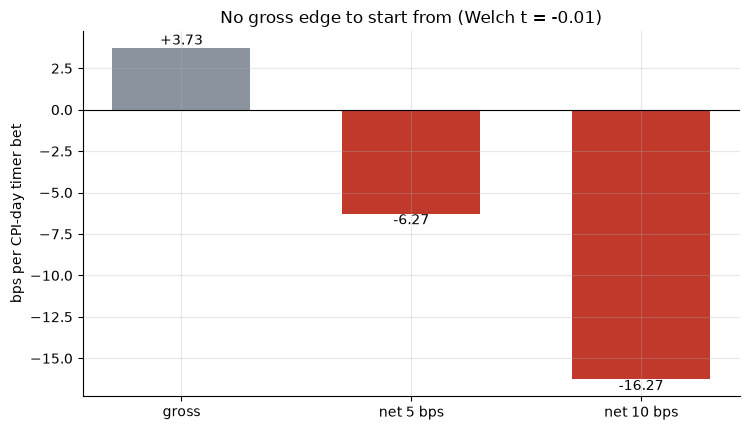

gross +3.73 -> net -6.27 / -16.27 bps  (t=-0.01, worst day -6.6%)


In [7]:
if HAVE_REAL:
    rows = [st.timer_capture(SPY, cost_bps=cb) for cb in (5.0, 10.0)]
    g = rows[0]['gross_bps']; n5, n10 = rows[0]['net_bps'], rows[1]['net_bps']
    tv, worst = rows[0]['welch_t'], rows[0]['worst_day_pct']
else:
    g, n5, n10 = R['tm_gross'], R['tm_net5'], R['tm_net10']
    tv, worst = R['tm_t'], R['tm_worst']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['gross','net 5 bps','net 10 bps'], [g, n5, n10], color=[GREY, RED, RED], width=.6)
for i,v in enumerate([g, n5, n10]): ax.annotate(f'{v:+.2f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('bps per CPI-day timer bet')
ax.set_title(f'No gross edge to start from (Welch t = {tv:+.2f})')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f} -> net {n5:+.2f} / {n10:+.2f} bps  (t={tv:+.2f}, worst day {worst:+.1f}%)')

> 💡 In plain words: the timer starts from **+3.73 bps** gross — barely distinguishable from the +3.80 bps SPY earns on an ordinary day (*t* = -0.01) — so any realistic cost (5-10 bps one-way) flips it negative (**-6.27 / -16.27 bps**, **-0.75% / -1.95%/yr**). There was never a directional edge to begin with; charging costs against nothing just produces a loss.

### 4g · Faithful-engine & power control — we know the truth here

Synthetic daily-return process, scheduled pseudo-CPI days every 21st business day, TWO independently tunable planted effects (a return-mean shift and a volatility multiplier). The null is checked over **20 seeds** — never a single stream — on BOTH axes, and each knob must be recovered WITHOUT contaminating the other.

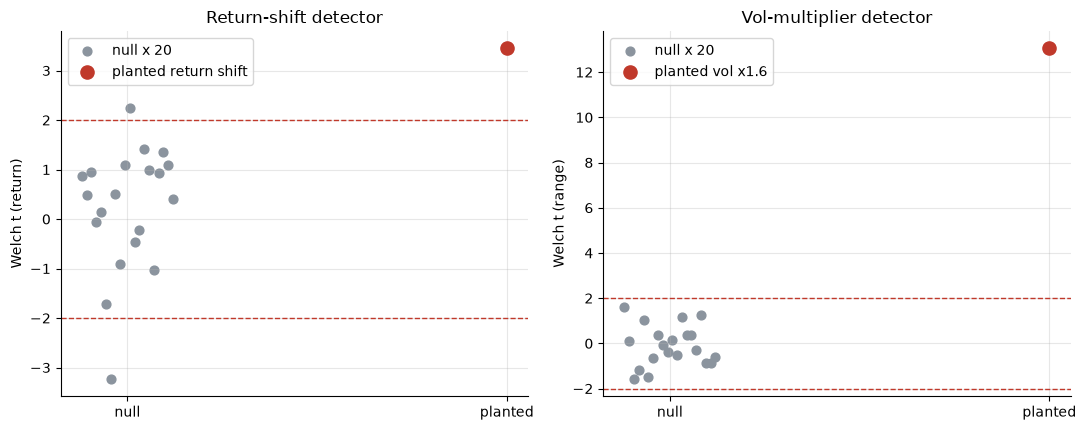

null: return mean t=+0.24 (sd 1.26), |t|>=2 in 2/20  |  range mean t=-0.11 (sd 0.91), |t|>=2 in 0/20
planted return shift t=+3.46  |  planted vol-mult range t=+13.07 (cross-contamination check, return t=+0.87)


In [8]:
null_ret, null_rng = [], []
for s_ in range(20):
    close, dec = data.synthetic_world(mu_shift=0.0, vol_mult=1.0, seed=644 + s_)
    d = st.synthetic_detect(close, dec)
    null_ret.append(d['welch_t']); null_rng.append(d['range_welch_t'])
null_ret = np.asarray(null_ret); null_rng = np.asarray(null_rng)
close, dec = data.synthetic_world(mu_shift=0.0015, vol_mult=1.0, seed=644)
planted_ret_t = st.synthetic_detect(close, dec)['welch_t']
close, dec = data.synthetic_world(mu_shift=0.0, vol_mult=1.6, seed=644)
d_rng = st.synthetic_detect(close, dec)
planted_rng_t, cross_ret_t = d_rng['range_welch_t'], d_rng['welch_t']
fig, (p1, p2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
p1.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ret, color=GREY, s=40, label='null x 20')
p1.scatter([1], [planted_ret_t], color=RED, s=90, zorder=5, label='planted return shift')
p1.axhline(-2, ls='--', c=RED, lw=1); p1.axhline(2, ls='--', c=RED, lw=1)
p1.set_xticks([0,1]); p1.set_xticklabels(['null','planted']); p1.set_ylabel('Welch t (return)')
p1.set_title('Return-shift detector'); p1.legend()
p2.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_rng, color=GREY, s=40, label='null x 20')
p2.scatter([1], [planted_rng_t], color=RED, s=90, zorder=5, label='planted vol x1.6')
p2.axhline(-2, ls='--', c=RED, lw=1); p2.axhline(2, ls='--', c=RED, lw=1)
p2.set_xticks([0,1]); p2.set_xticklabels(['null','planted']); p2.set_ylabel('Welch t (range)')
p2.set_title('Vol-multiplier detector'); p2.legend()
plt.tight_layout(); plt.show()
print(f'null: return mean t={null_ret.mean():+.2f} (sd {null_ret.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ret)>=2).sum()}/20  |  range mean t={null_rng.mean():+.2f} '
      f'(sd {null_rng.std(ddof=1):.2f}), |t|>=2 in {(abs(null_rng)>=2).sum()}/20')
print(f'planted return shift t={planted_ret_t:+.2f}  |  planted vol-mult range '
      f't={planted_rng_t:+.2f} (cross-contamination check, return t={cross_ret_t:+.2f})')

> 💡 In plain words: across 20 null worlds neither detector fires (return mean *t* = +0.24, 2/20 crossing the bar by chance; range mean *t* = -0.11, 0/20). A planted +15 bp return shift reads *t* = 3.46; a planted 1.6× vol multiplier reads range *t* = 13.07 **without** contaminating the return detector (*t* = 0.87, small). The machinery can catch either the direction effect or the loudness effect independently — exactly what the real-tape split (real on TLT range, none on return) requires it to be capable of. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `MIXED`** — real on one leg, none on the rest: TLT's realized range is genuinely elevated on CPI mornings (Welch *t* = **2.70**, one-sided placebo *p* = **0.00025**), mechanically sound (CPI directly re-prices rate expectations). SPY return (*t* = -0.01), TLT return (*t* = 0.67) and SPY's own range (*t* = 0.82, placebo *p* = 0.18350) all fail the **t ≥ 2** bar.
- **Tradability `MIRAGE`** — no directional edge exists to bank; the naive SPY timer nets **-6.27 bps/event** (≈-0.75%/yr) at 5 bps costs, starting from a non-edge. The one certified effect (TLT range) needs an options/vol instrument to harvest, which this study doesn't test and which the FOMC precedent (637) suggests is pre-priced ahead of the print.
- **"Biggest day of the month"? `BUSTED`** — every metric drifts the "more true since 2022" way, best case TLT range diff *t* = **1.31**, but none of the four pre/post differences clears *t* = 2, and even the strongest post-2022 rate (15.1% of months) is a small minority — not literally "the" biggest day.

## 6 · Going further

- **The general object is the scheduled-data-release premium.** Faust, Rogers, Wang & Wright (2007) and Balduzzi, Elton & Green (2001) document fast, sharp fixed-income reactions to macro surprises specifically — the mechanism behind why TLT, not SPY, carries this study's certified effect.
- **The natural sequel is an options-based test.** If bond volatility genuinely spikes on CPI day, the honest way to ask whether that's bankable is a straddle or variance-swap backtest on rates around the print — not a directional cash-bond position, which this study shows has nothing to offer.
- **Dedup map:** [602-macro-announcement-premium](../../602-macro-announcement-premium/) (the pooled FOMC+CPI+NFP Savor-Wilson premium — traces almost entirely to FOMC, not CPI), [643-payrolls-day-effect](../../643-payrolls-day-effect/) (identical protocol, Nonfarm Payrolls mornings instead), [637-fomc-vol-crush](../../637-fomc-vol-crush/) (the FOMC decision *afternoon* — implied vol, not realized range, and the cautionary tale that a real vol effect can still be untradable).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*